In [204]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math


In [185]:
# Load dataset
df = pd.read_csv("AAPL.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9909 entries, 1980-12-12 to 2020-04-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       9909 non-null   float64
 1   High       9909 non-null   float64
 2   Low        9909 non-null   float64
 3   Close      9909 non-null   float64
 4   Adj Close  9909 non-null   float64
 5   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 541.9 KB


In [187]:
# Calculate the time difference between consecutive days
df['TimeDiff'] = df.index.to_series().diff().dt.days.fillna(0).astype(int)

In [188]:
df['SMA_5'] = df['Close'].rolling(window=5).mean()  # 5-day Simple Moving Average
df['SMA_10'] = df['Close'].rolling(window=10).mean()  # 10-day Simple Moving Average
df['SMA_20'] = df['Close'].rolling(window=20).mean()  # 20-day Simple Moving Average
df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()  # 5-day Exponential Moving Average
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
df['Rolling_SD_5'] = df['Close'].rolling(window=5).std()  # 5-day Rolling Standard Deviation
df['Rolling_SD_10'] = df['Close'].rolling(window=10).std()  # 10-day Rolling Standard Deviation
df['Rolling_SD_20'] = df['Close'].rolling(window=20).std()  # 20-day Rolling Standard Deviation
df['Range'] = df['High'] - df['Low']                   # Daily range
df['Body'] = df['Close'] - df['Open']                  # Candle body
df['Pct_Change'] = (df['Close'] - df['Open']) / df['Open']  # Percent change
df['ExpandingMean'] = df['Close'].expanding().mean()
df['ExpandingStd'] = df['Close'].expanding().std()

df = df.dropna()

In [189]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,TimeDiff,SMA_5,SMA_10,SMA_20,...,EMA_10,EMA_20,Rolling_SD_5,Rolling_SD_10,Rolling_SD_20,Range,Body,Pct_Change,ExpandingMean,ExpandingStd
Date,,,,,,,,,,,,,,,,,,,,,
1981-01-12,0.569196,0.569196,0.564732,0.564732,0.447460,5924800,3,0.560268,0.589955,0.554353,...,0.570814,0.561104,0.014380,0.034388,0.058572,0.004464,-0.004464,-0.007843,0.554353,0.058572
1981-01-13,0.546875,0.546875,0.544643,0.544643,0.431542,5762400,1,0.554018,0.580134,0.555915,...,0.566056,0.559536,0.012568,0.031505,0.057834,0.002232,-0.002232,-0.004082,0.553890,0.057128
1981-01-14,0.546875,0.549107,0.546875,0.546875,0.433311,3572800,1,0.553125,0.572098,0.558929,...,0.562568,0.558330,0.012958,0.028236,0.055558,0.002232,0.000000,0.000000,0.553571,0.055772
1981-01-15,0.558036,0.562500,0.558036,0.558036,0.442154,3516800,1,0.556696,0.566964,0.564286,...,0.561744,0.558302,0.010775,0.025210,0.049419,0.004464,0.000000,0.000000,0.553766,0.054497
1981-01-16,0.555804,0.555804,0.553571,0.553571,0.438617,3348800,1,0.553571,0.560714,0.568862,...,0.560258,0.557851,0.008201,0.018551,0.043315,0.002232,-0.002232,-0.004016,0.553757,0.053299


In [190]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume,TimeDiff,SMA_5,SMA_10,SMA_20,...,EMA_10,EMA_20,Rolling_SD_5,Rolling_SD_10,Rolling_SD_20,Range,Body,Pct_Change,ExpandingMean,ExpandingStd
count,9890.000000,9890.000000,9890.000000,9890.000000,9890.000000,9.890000e+03,9890.000000,9890.000000,9890.000000,9890.000000,...,9890.000000,9890.000000,9890.000000,9890.000000,9890.000000,9890.000000,9890.000000,9890.000000,9890.000000,9890.000000
mean,32.668425,32.998285,32.338505,32.679630,30.634469,8.595450e+07,1.448635,32.629513,32.566995,32.441244,...,32.566365,32.432520,0.488706,0.682486,0.972771,0.659780,0.011205,-0.000125,4.652205,7.672579
std,58.454937,59.041140,57.921895,58.511134,56.785369,8.600022e+07,0.874372,58.422159,58.314321,58.093380,...,58.300783,58.032741,1.118300,1.443994,1.985635,1.423190,0.915907,0.023537,7.271480,13.479723
min,0.198661,0.198661,0.196429,0.196429,0.155638,3.472000e+05,1.000000,0.203571,0.212946,0.223996,...,0.213186,0.222436,0.001223,0.002220,0.004277,0.000000,-17.939987,-0.243523,0.375755,0.046742
25%,1.074353,1.098214,1.053571,1.073996,0.920743,3.314150e+07,1.000000,1.076875,1.075670,1.083522,...,1.083311,1.095410,0.020213,0.029523,0.042129,0.035714,-0.035714,-0.011674,0.846210,0.499263
50%,1.732143,1.766786,1.696429,1.735357,1.468612,5.772795e+07,1.000000,1.725875,1.718473,1.719554,...,1.720017,1.720311,0.047869,0.067094,0.092309,0.073661,0.000000,0.000000,1.200026,0.750042
75%,35.965001,36.380713,35.508570,35.960715,31.215370,1.070528e+08,1.000000,35.845571,36.195071,36.059821,...,36.238119,36.094747,0.495189,0.748475,1.114770,0.747143,0.037946,0.010870,4.113304,6.965973
max,324.739990,327.850006,323.350006,327.200012,327.200012,1.855410e+09,7.000000,323.928003,322.748999,319.860001,...,322.018406,318.735161,19.286287,20.555314,23.982313,26.970016,16.529999,0.192661,32.618030,58.471899


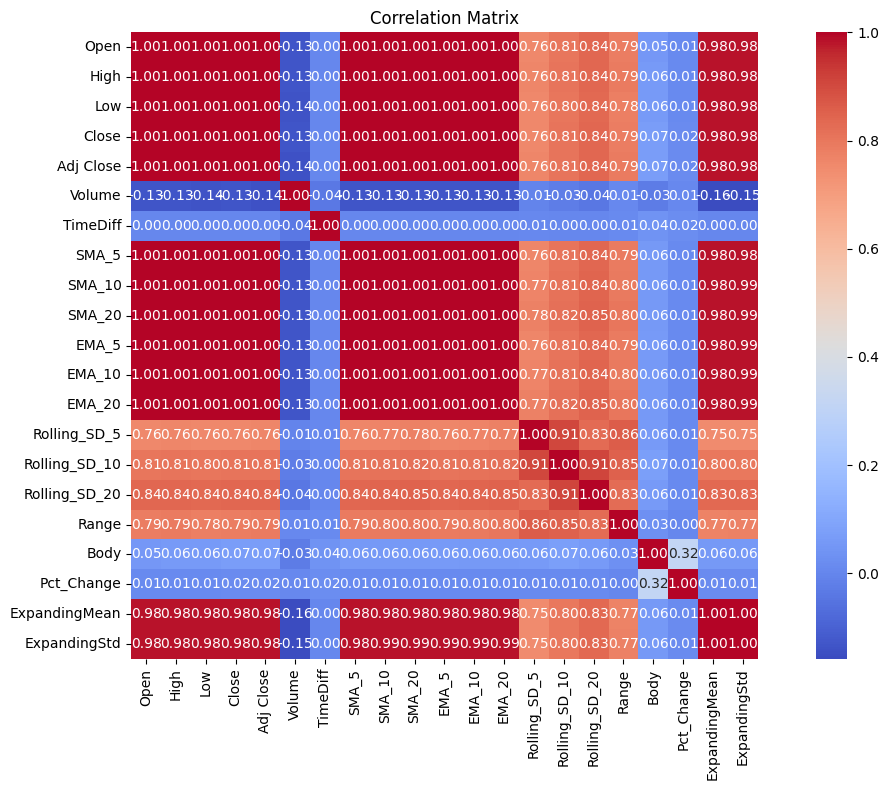

In [191]:
corr_matrix = df.corr()

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [192]:
# Define the features and target
# features = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'EMA_20', 'Range', 'Body', 'Pct_Change']
features = ['Open', 'Volume', 'TimeDiff',
            'SMA_5', 'SMA_10', 'SMA_20',
            'EMA_5', 'EMA_10', 'EMA_20',
            'Range', 'Body', 'Pct_Change',
            'Rolling_SD_5', 'Rolling_SD_10', 'Rolling_SD_20',
            'ExpandingMean', 'ExpandingStd']
target = 'Close'
# features = ['Close', 'Range', 'Body', 'Pct_Change', 'EMA_5', 'EMA_10']
# target = 'Close'

# Prepare input and output
X = df[features].values  # Features (input)
y = df[target].values    # Target (output)

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Scale the features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale the target
target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1))

In [193]:
print(X_train_scaled.shape)
print(y_train_scaled.shape)
print(X_test_scaled.shape)
print(y_test_scaled.shape)

(7912, 17)
(7912, 1)
(1978, 17)
(1978, 1)


In [194]:
SEQ_LENGTH =  30
def createSequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i+seq_length])  # Past 'seq_length' days
        ys.append(y[i+seq_length])  # Predict next day's Close
    return torch.tensor(np.array(Xs), dtype=torch.float32), torch.tensor(np.array(ys), dtype=torch.float32)

In [195]:
X_train_seq, y_train_seq = createSequences(X_train_scaled, y_train_scaled, SEQ_LENGTH)
X_test_seq, y_test_seq = createSequences(X_test_scaled, y_test_scaled, SEQ_LENGTH)

In [196]:
print(X_train_seq.shape)
print(y_train_seq.shape)
print(X_test_seq.shape)
print(y_test_seq.shape)

torch.Size([7882, 30, 17])
torch.Size([7882, 1])
torch.Size([1948, 30, 17])
torch.Size([1948, 1])


In [197]:
class StockPriceLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout_prob):
        super(StockPriceLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm1 = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout1 = nn.Dropout(dropout_prob)

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out1, _ = self.lstm1(x, (h0, c0))
        out1 = self.dropout1(out1)

        out = self.fc(out1[:, -1, :])  # Use last time step
        return out


In [198]:
# Hyperparameters
input_size = X_train_seq.shape[2]  # Number of features
hidden_size = 200 # Number of LSTM neurons
num_layers = 1  # Number of stacked LSTM layers
dropout_prob = 0.2
learning_rate = 0.0005 #0.0005

# Instantiate the model
model = StockPriceLSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, dropout_prob=dropout_prob)

# Define loss and optimizer (L2 regulization)
# criterion = nn.MSELoss()
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

# Learning Rate Scheduler (ReduceLROnPlateau)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.75, patience=5, min_lr=1e-5)


In [199]:
# from sklearn.metrics import mean_squared_error

# # Convert data to tensors for PyTorch
# X_train_seq_tensor = torch.tensor(X_train_seq).clone().detach().float()
# y_train_seq_tensor = torch.tensor(y_train_seq).clone().detach().float()

# X_test_seq_tensor = torch.tensor(X_test_seq).clone().detach().float()
# y_test_seq_tensor = torch.tensor(y_test_seq).clone().detach().float()


# # Training loop
# num_epochs = 100
# best_val_loss = float('inf')
# patience = 30 #10
# counter = 0

# # Collect Losses for plotting
# train_losses = []
# val_losses = []

# for epoch in range(num_epochs):
#     model.train()

#     # Forward pass
#     outputs = model(X_train_seq_tensor)
#     loss = criterion(outputs, y_train_seq_tensor)

#     # Backward pass and optimization
#     optimizer.zero_grad()
#     loss.backward()
#     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
#     optimizer.step()

#     # Validation loss
#     model.eval()
#     with torch.no_grad():
#         val_outputs = model(X_test_seq_tensor)
#         val_outputs_np = val_outputs.detach().numpy().reshape(-1, 1)
#         y_test_np = y_test_seq_tensor.detach().numpy().reshape(-1, 1)
#         val_loss = mean_squared_error(y_test_np, val_outputs_np)

#     # Record losses
#     train_losses.append(loss.item())
#     val_losses.append(val_loss)

#     # Early stopping check
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         counter = 0
#         torch.save(model.state_dict(), 'lstmBestModel.pth')  # Save best model
#     else:
#         counter += 1

#     if counter > patience:
#         print(f'Early stopping at epoch {epoch}')
#         print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}, Current Learning Rate: {current_lr:.6f}')
#         break

#     # Print training stats
#     if epoch % 5 == 0:
#         current_lr = optimizer.param_groups[0]['lr']
#         print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}, Current Learning Rate: {current_lr:.6f}')
#     scheduler.step(val_loss)


In [200]:
num_epochs = 100
best_val_loss = float('inf')
patience = 15
counter = 0
batch_size = 64
# Convert data to tensors
X_train_seq_tensor = torch.tensor(X_train_seq).clone().detach().float()
y_train_seq_tensor = torch.tensor(y_train_seq).clone().detach().float()

X_test_seq_tensor = torch.tensor(X_test_seq).clone().detach().float()
y_test_seq_tensor = torch.tensor(y_test_seq).clone().detach().float()

# Create DataLoader for training
train_dataset = TensorDataset(X_train_seq_tensor, y_train_seq_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Track losses for training and validation
train_losses = []
val_losses = []

# Training loop
start_time = time.time()
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)  # Accumulate batch loss weighted by batch size

    avg_train_loss = epoch_loss / len(train_loader.dataset)

    # Validation loss
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_seq_tensor)
        val_outputs_np = val_outputs.detach().numpy().reshape(-1, 1)
        y_test_np = y_test_seq_tensor.detach().numpy().reshape(-1, 1)
        val_loss = mean_squared_error(y_test_np, val_outputs_np)

    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), 'lstmBestModel.pth')
    else:
        counter += 1

    if counter > patience:
        print(f'Early stopping at epoch {epoch}')
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, Current Learning Rate: {current_lr:.6f}')
        break

    if epoch % 5 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, Current Learning Rate: {current_lr:.6f}')

    scheduler.step(val_loss)

total_time = time.time() - start_time
print(f"\n🕒 Total training time: {total_time:.2f} seconds")


<ipython-input-200-b42b59f1d671>:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_seq_tensor = torch.tensor(X_train_seq).clone().detach().float()
<ipython-input-200-b42b59f1d671>:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_seq_tensor = torch.tensor(y_train_seq).clone().detach().float()
<ipython-input-200-b42b59f1d671>:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_seq_tensor = torch.tensor(X_test_seq).clone().detach().float()
<ipython-input-200-b42b59f1d671>:11: UserWarning: To copy construct from a tensor, 

Epoch [0/100], Loss: 0.0222, Val Loss: 0.0720, Current Learning Rate: 0.000500
Epoch [5/100], Loss: 0.0048, Val Loss: 0.0566, Current Learning Rate: 0.000500
Epoch [10/100], Loss: 0.0043, Val Loss: 0.0281, Current Learning Rate: 0.000500
Epoch [15/100], Loss: 0.0038, Val Loss: 0.0372, Current Learning Rate: 0.000500
Epoch [20/100], Loss: 0.0034, Val Loss: 0.0216, Current Learning Rate: 0.000375
Epoch [25/100], Loss: 0.0034, Val Loss: 0.0303, Current Learning Rate: 0.000375
Epoch [30/100], Loss: 0.0032, Val Loss: 0.0316, Current Learning Rate: 0.000281
Epoch [35/100], Loss: 0.0031, Val Loss: 0.0118, Current Learning Rate: 0.000211
Epoch [40/100], Loss: 0.0031, Val Loss: 0.0138, Current Learning Rate: 0.000211
Epoch [45/100], Loss: 0.0029, Val Loss: 0.0098, Current Learning Rate: 0.000158
Epoch [50/100], Loss: 0.0030, Val Loss: 0.0184, Current Learning Rate: 0.000158
Epoch [55/100], Loss: 0.0030, Val Loss: 0.0158, Current Learning Rate: 0.000119
Epoch [60/100], Loss: 0.0029, Val Loss: 0.

In [205]:
# Make predictions
model.eval()
with torch.no_grad():
    predictions = model(X_test_seq_tensor)

# Convert predictions to numpy and reshape to match inverse_transform (2D array)
predictions = predictions.numpy().reshape(-1, 1)  # Reshaping to (num_samples, 1)
y_test_numpy = y_test_seq.numpy().reshape(-1, 1)

# Inverse transform to get predictions and y_test back to original scale
predictions_original = target_scaler.inverse_transform(predictions)  # Scale back the predictions
y_test_original = target_scaler.inverse_transform(y_test_numpy)  # Scale back the actual values

# Undo the log transformation if applied (np.exp)
# predictions_original = np.exp(predictions_original)
# y_test_original = np.exp(y_test_original)

# mse = mean_squared_error(y_test_original, predictions_original)
# print(f"Mean Squared Error (MSE): {mse}")

# calculate evaluation metrics
mae = mean_absolute_error(y_test_original, predictions_original)
r2 = r2_score(y_test_original, predictions_original)
mse = mean_squared_error(y_test_original, predictions_original)
rmse = math.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

thresholds = [0.01, 0.02, 0.05, 0.1]  # 1%, 2%, 5%, 10%
error = np.abs((predictions_original - y_test_original) / y_test_original)

for threshold in thresholds:
    accuracy = np.mean(error < threshold)
    print(f"Accuracy (within {threshold * 100}% margin): {accuracy * 100:.2f}%")


Mean Absolute Error (MAE): 7.3132
R-squared (R²): 0.9527
Mean Squared Error (MSE): 158.0697
Root Mean Squared Error (RMSE): 12.5726
Accuracy (within 1.0% margin): 14.43%
Accuracy (within 2.0% margin): 30.54%
Accuracy (within 5.0% margin): 71.05%
Accuracy (within 10.0% margin): 93.22%


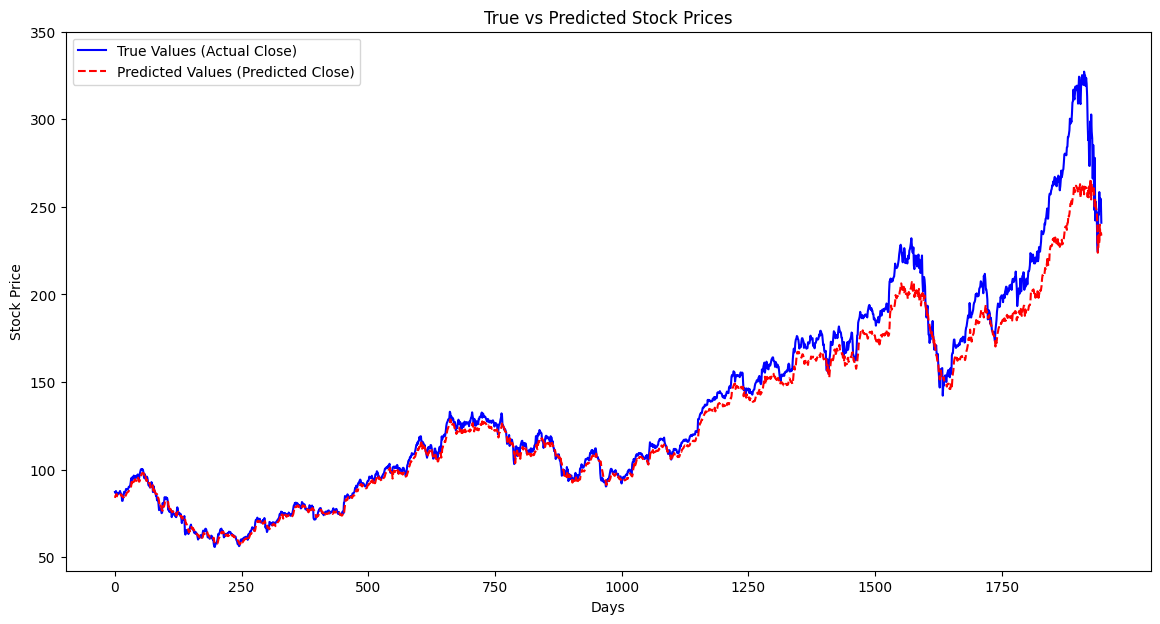

In [202]:
import matplotlib.pyplot as plt

# Plot the true vs predicted values
plt.figure(figsize=(14,7))
plt.plot(y_test_original, label='True Values (Actual Close)', color='blue')
plt.plot(predictions_original, label='Predicted Values (Predicted Close)', color='red', linestyle='--')

# Add labels and a legend
plt.title('True vs Predicted Stock Prices')
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.legend()

# Customize the x-axis ticks
plt.xticks(range(0, len(y_test_original), 250))  # This will set x-ticks at intervals of 250
plt.yticks(range(50, 400, 50))

# Show the plot
plt.show()


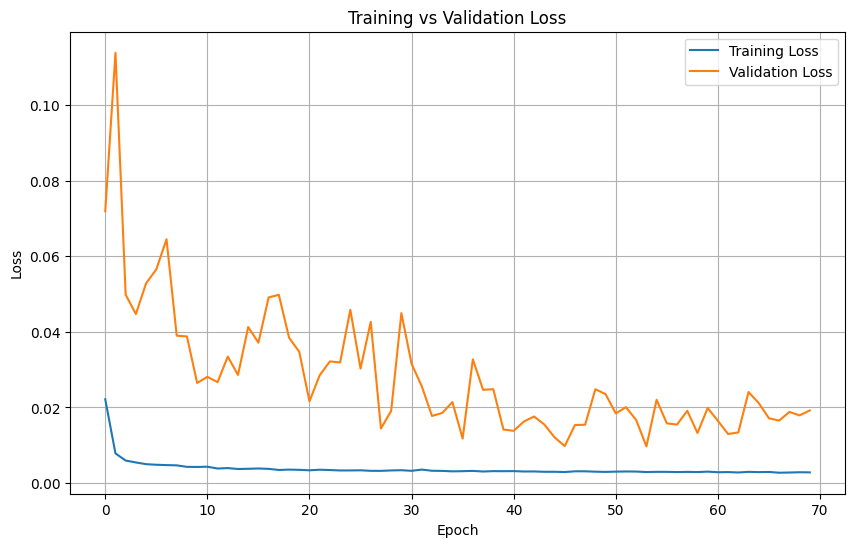

In [203]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()
